# Cobertura de semilla: el cuello de botella

El 61 % de las pseudohuérfanas tiene **semilla nula**: ningún vecino químico con
blanco conocido. Mientras eso siga así ninguna reponderación mueve el número —las
iteraciones it0–it3 de v3 dieron resultados idénticos, que es exactamente lo que
se espera si la limitación es estructural.

Este notebook mide el techo de las tres palancas, sin re-correr el modelo:

  * **umbral de similitud química** — la capa guardada sólo conserva pares con
    similitud ≥ 0.8, así que desde acá sólo se puede subir; bajarlo exige
    recalcular sobre los fingerprints crudos (no disponibles en este repositorio);
  * **KEGG** como tercera fuente de afiliaciones — rescata semillas *no
    informativas*, no nulas: agrega categorías, no vecinos;
  * **capa fenotípica** como semilla de respaldo — no da un blanco proteico, da
    una especie; es la información más débil, que el paper descarta explícitamente.

Origen: el análisis de cobertura de la versión v3 (fuera de este repositorio).
Salidas: `02_cobertura_por_droga.csv`, `02_cobertura_por_especie.csv`, `02_palancas.csv`.

## Imports

In [1]:
import sys, os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")          # antes de numpy: un hilo por proceso

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from pathlib import Path
# raiz del repositorio: se busca hacia arriba la carpeta que tiene DB/,
# asi el notebook corre desde donde sea que se haya clonado
RAIZ = Path.cwd()
while not (RAIZ / "DB").is_dir() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "comun"))
sys.path.insert(0, str(RAIZ / "huerfanas"))
%load_ext autoreload
%autoreload 2
import tdr, nucleo as nf
import funciones_huerfanas as fh              # el .py de esta carpeta
import figuras as F                        # comun/figuras.py: las figuras, desde las tablas

SALIDAS = tdr.out("huerfanas")
FIGURAS = SALIDAS / "figuras"
NB      = "02"                             # numero de este notebook: prefija todo lo que genere
n_core  = tdr.N_CORE_DEFAULT                # 20 salvo TDR_NCORE

plt = tdr.estilo()
SALIDAS

PosixPath('/data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out')

## Datos

In [2]:
# cluster_consistent=True: `huerfanas/` filtra los positivos/negativos
# inconsistentes a nivel cluster, como en la versión v3.
crudo = tdr.cargar_db(anotaciones=True, quimica=True, fenotipo=True, cluster_consistent=True)

# CONVENCIONES.md §10: el filtro de promiscuidad se APLICA antes de armar ninguna semilla.
# La lista sale de analiceDB/03; si falta, el error dice qué correr.
promiscuos = tdr.compuestos_promiscuos()
datos = tdr.filtrar_capa_quimica(crudo, promiscuos)

HUERFANAS = tdr.out("huerfanas")
res01 = fh.cargar_resultados(HUERFANAS, "01", patron="*_pseudohuerfanas")
res01["semilla"].value_counts(normalize=True)

· 00_specie_target


· 03_bioactivities_target_compound


· 04a_interpro / 04b_orthomcl


· 01/02 clusters y aristas quimicas (pesado)


· 03_bioactivities_organism_compound


filtro de promiscuidad (MW < 150 y N_parentales > 100): 5 compuestos


  sclus 831175 -> 831170 (0.00 % removido)


  dds   440 -> 440 (0.00 % removido)


semilla
nula              0.677589
informativa       0.175405
no informativa    0.147006
Name: proportion, dtype: float64

## Acondicionamiento

In [3]:
k1, posdt_sp = fh.construir_pseudohuerfanas(datos)
# La palanca se evalúa sobre las que hoy NO son informativas: es el universo a rescatar
a_rescatar = res01.loc[res01["semilla"] != "informativa", ["drug_id", "especie"]]
muestra = (k1.merge(a_rescatar.rename(columns={"especie": "sp_id"}), on=["drug_id", "sp_id"])
           .pipe(fh.muestra_pseudohuerfanas, n=500))
print(f"{len(muestra)} drogas a rescatar, de {len(res01)} evaluadas en el notebook 01")
muestra["grupo"].value_counts().sort_index()

pseudohuerfanas: 60253 drogas, 26 especies, grupos {0: 22375, 1: 17306, 2: 9830, 3: 10742}


500 drogas a rescatar, de 7782 evaluadas en el notebook 01


grupo
0    206
1     86
2    146
3     62
Name: count, dtype: int64

## Corrida

In [4]:
# celda de corrida: el ciclo se lee aca
palancas = []
for palanca, kw in [("umbral", {"umbral": 0.9}),
                    ("kegg", {"mapa_kegg": None}),      # pasar el mapeo si se consiguió
                    ("fenotipo", {})]:
    palancas.append(fh.cobertura_por_palanca(datos, palanca, muestra, **kw))
pal = pd.concat(palancas, ignore_index=True)

cob_esp = (res01.groupby(["especie", "semilla"]).size().unstack(fill_value=0)
           .assign(techo=lambda d: d.get("informativa", 0) / d.sum(axis=1)))

pal.to_csv(SALIDAS / f"{NB}_palancas.csv", index=False)
res01[["drug_id", "especie", "semilla", "n_semilla"]].to_csv(
    SALIDAS / f"{NB}_cobertura_por_droga.csv", index=False)
cob_esp.to_csv(SALIDAS / f"{NB}_cobertura_por_especie.csv")
fh.escribir_meta(SALIDAS, NB, notebook="02_cobertura_semilla.ipynb",
                 params={"umbral": 0.9, "n_muestra": len(muestra)},
                 fuente_nb="01", filtro_promiscuidad=True)

palanca umbral: rescata 0 de 500 (0.0%)


palanca kegg: rescata 0 de 500 (0.0%)


palanca fenotipo: rescata 0 de 500 (0.0%)


  meta -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out/02_meta.json


{'notebook': '02_cobertura_semilla.ipynb',
 'nb': '02',
 'fecha': '2026-09-24 16:28',
 'params': {'umbral': 0.9, 'n_muestra': 500},
 'n_core': None,
 'tablas_db': {'00_specie_target.csv': '2026-09-08',
  '01_clusters_fingerprint.csv': '2026-09-08',
  '01_edges_clusters_fingerprint.part00.csv.gz': '2026-09-08',
  '01_edges_clusters_fingerprint.part01.csv.gz': '2026-09-08',
  '02_clusters_subestructure.csv': '2026-09-08',
  '02_edges_clusters_subestructure.csv': '2026-09-08',
  '03_bioactivities_organism_compound.csv': '2026-09-08',
  '03_bioactivities_target_compound.csv': '2026-09-08',
  '04a_interpro.csv': '2026-09-08',
  '04b_orthomcl.csv': '2026-09-08'},
 'python': '3.12.11',
 'pandas': '3.0.5',
 'fuente_nb': '01',
 'filtro_promiscuidad': True}

# Resultados

Desde acá no se toca la base: cada figura lee sus tablas de `resultados/` y la
dibuja `F.dibujar(...)` (las funciones están en `figuras_huerfanas.py`). Para
regenerarlas sin volver a pagar la corrida alcanza con la celda de imports y esta
sección, o, desde la raíz del repositorio:

    python comun/figuras.py huerfanas

In [5]:
pal     = pd.read_csv(SALIDAS / f"{NB}_palancas.csv")
cob_esp = pd.read_csv(SALIDAS / f"{NB}_cobertura_por_especie.csv", index_col=0)
cob_esp.round(3)

,informativa,no informativa,nula,techo
especie,,,,
0,139,101,760,0.139
1,169,118,713,0.169
3,215,86,699,0.215
4,6,10,137,0.039
5,10,8,20,0.263
9,83,152,266,0.166
10,143,213,644,0.143
15,63,17,156,0.267
17,29,25,116,0.171


  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out/figuras/02_f02_palancas.pdf


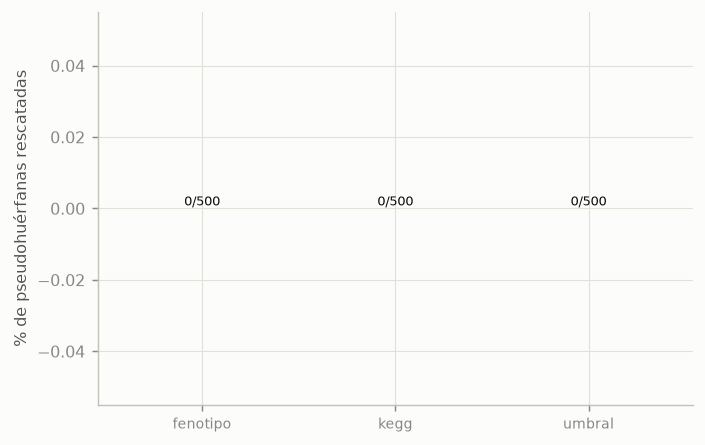

In [6]:
F.dibujar("02_f02_palancas");

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out/figuras/02_f03_techo_teorico.pdf


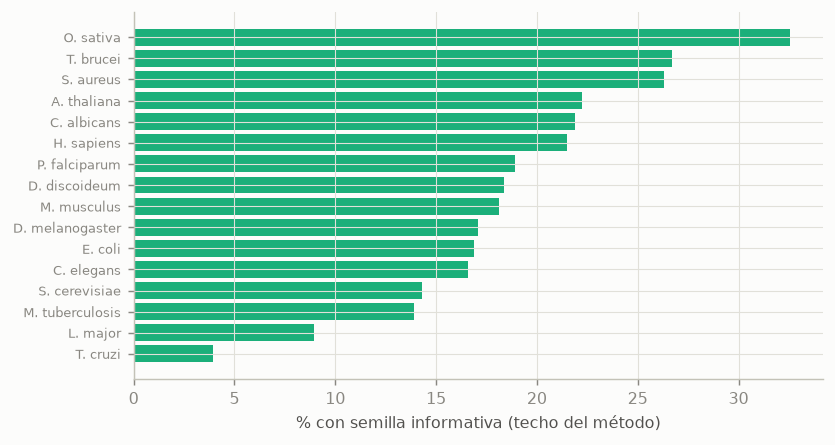

In [7]:
# Techo teórico: ninguna reponderación puede superar la fracción informativa
F.dibujar("02_f03_techo_teorico");